# Customer Segmentation using RFM-style Features and K-Means

## Bước 7 - Customer Segmentation

Mục tiêu:
- Phân khúc khách hàng dựa trên hành vi mua hàng theo hướng RFM.
- Sử dụng K-Means để nhóm khách hàng có đặc điểm tương đồng.
- Hỗ trợ mô tả nhóm khách hàng và chiến lược chăm sóc.

Lưu ý phương pháp:
- Notebook này **không tạo lại churn label** và **không thay thế `churn_180`**.
- `churn_180` chỉ được dùng sau khi clustering để mô tả tỷ lệ churn quan sát theo cluster.
- Pipeline hiện tại không còn các cột cũ `recency_days`, `frequency_orders`, `monetary_matched_total`.
- Vì vậy notebook xây dựng lại bộ RFM-style từ dataset feature đã chọn:
  - **Recency**: số ngày từ snapshot gần nhất của khách hàng đến mốc phân tích chung.
  - **Frequency**: `orders_last_180d` tại snapshot gần nhất.
  - **Monetary**: `monetary_total` tại snapshot gần nhất.
- Đây là RFM-style theo cấu trúc dữ liệu hiện tại; Frequency là số đơn trong cửa sổ 180 ngày, không phải lifetime frequency.


## 01. Setup


In [1]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import Imputer

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

drive.mount('/content/drive', force_remount=False)

spark = (
    SparkSession.builder
    .appName('CustomerSegmentationRFM')
    .getOrCreate()
)

data_dir = Path('/content/drive/MyDrive/BigData/DA-BigData/code/data')
processed_dir = data_dir / 'processed'
selected_feature_dir = processed_dir / 'olist_customer_churn_features_selected'

print('Data directory           :', data_dir)
print('Processed directory      :', processed_dir)
print('Selected feature dataset :', selected_feature_dir)


Mounted at /content/drive
Data directory           : /content/drive/MyDrive/BigData/DA-BigData/code/data
Processed directory      : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed
Selected feature dataset : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_churn_features_selected


## 02. Load Final Feature Dataset

Sử dụng output của bước Feature Engineering hiện tại. Không đọc lại schema cũ và không gọi các feature đã bị loại.


In [2]:
if not selected_feature_dir.exists():
    raise FileNotFoundError(
        f'Không tìm thấy dataset: {selected_feature_dir}'
    )

segmentation_base = (
    spark.read
    .option('header', True)
    .option('inferSchema', True)
    .csv(str(selected_feature_dir))
)

required_columns = [
    'customer_unique_id',
    'snapshot_order_id',
    'snapshot_at',
    'snapshot_date',
    'churn_180',
    'orders_last_180d',
    'monetary_total'
]

missing_columns = sorted(
    set(required_columns) - set(segmentation_base.columns)
)

if missing_columns:
    raise ValueError(
        f'Dataset thiếu các cột bắt buộc: {missing_columns}'
    )

print('Rows:', f'{segmentation_base.count():,}')
print('Columns:', len(segmentation_base.columns))
print()
print('Required columns are available.')

segmentation_base.select(*required_columns).printSchema()


Rows: 58,372
Columns: 34

Required columns are available.
root
 |-- customer_unique_id: string (nullable = true)
 |-- snapshot_order_id: string (nullable = true)
 |-- snapshot_at: timestamp (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- churn_180: integer (nullable = true)
 |-- orders_last_180d: integer (nullable = true)
 |-- monetary_total: double (nullable = true)



## 03. Build Customer-level RFM-style Dataset

Dataset churn hiện tại có nhiều purchase-event snapshot cho cùng một khách hàng. Để clustering ở customer-level, mỗi `customer_unique_id` chỉ giữ snapshot gần nhất trong dataset đã chọn.

Mốc phân tích chung là ngày lớn nhất của `snapshot_date` trong dataset này.


In [3]:
window_latest = (
    Window
    .partitionBy('customer_unique_id')
    .orderBy(
        F.col('snapshot_at').desc_nulls_last(),
        F.col('snapshot_order_id').desc_nulls_last()
    )
)

customer_level = (
    segmentation_base
    .filter(F.col('customer_unique_id').isNotNull())
    .withColumn('row_num', F.row_number().over(window_latest))
    .filter(F.col('row_num') == 1)
    .drop('row_num')
    .cache()
)

analysis_cutoff = (
    segmentation_base
    .select(F.max('snapshot_date').alias('analysis_cutoff'))
    .first()['analysis_cutoff']
)

if analysis_cutoff is None:
    raise ValueError('Không xác định được analysis_cutoff từ snapshot_date')

rfm_data = (
    customer_level
    .select(
        'customer_unique_id',
        'snapshot_order_id',
        'snapshot_at',
        'snapshot_date',
        F.col('churn_180').cast('int').alias('churn_180'),
        F.datediff(
            F.lit(analysis_cutoff).cast('date'),
            F.col('snapshot_date')
        ).cast('double').alias('recency_days'),
        F.col('orders_last_180d').cast('double').alias('frequency_orders'),
        F.col('monetary_total').cast('double').alias('monetary_total')
    )
    .cache()
)

customer_count = rfm_data.select('customer_unique_id').distinct().count()
duplicate_count = (
    rfm_data
    .groupBy('customer_unique_id')
    .count()
    .filter(F.col('count') > 1)
    .count()
)

print('Analysis cutoff   :', analysis_cutoff)
print('Customer count    :', f'{customer_count:,}')
print('Duplicate customer:', duplicate_count)

if duplicate_count != 0:
    raise ValueError('Customer-level dataset vẫn còn duplicate customer_unique_id')

rfm_data.show(5, truncate=False)


Analysis cutoff   : 2018-08-22
Customer count    : 56,487
Duplicate customer: 0
+--------------------------------+--------------------------------+-------------------+-------------+---------+------------+----------------+--------------+
|customer_unique_id              |snapshot_order_id               |snapshot_at        |snapshot_date|churn_180|recency_days|frequency_orders|monetary_total|
+--------------------------------+--------------------------------+-------------------+-------------+---------+------------+----------------+--------------+
|000c8bdb58a29e7115cfc257230fb21b|34801c59d6ec5c5e89bfefb6ebef314d|2017-12-12 22:53:35|2017-12-12   |1        |253.0       |1.0             |29.0          |
|0078bb0f0d23e922d08437b7d0e13907|67e871df7739d67a0a128b9e66a3620b|2017-12-21 23:56:54|2017-12-21   |1        |244.0       |1.0             |44.09         |
|0098f4847541cc7d676f9a5efc64c0f0|d4fea5f1166ef240cfe766769f4d5ab0|2017-04-17 18:46:05|2017-04-17   |1        |492.0       |1.0        

## 04. Missing Value and Basic QA

K-Means không chấp nhận NaN. Median được học trên toàn bộ tập segmentation vì đây là bài toán unsupervised customer segmentation, không phải bước fit mô hình churn.


In [4]:
rfm_features = [
    'recency_days',
    'frequency_orders',
    'monetary_total'
]

missing_exprs = []
for c in rfm_features:
    missing_exprs.append(
        F.sum(
            F.when(
                F.col(c).isNull() | F.isnan(F.col(c)),
                1
            ).otherwise(0)
        ).alias(c)
    )

print('Missing trước imputation:')
rfm_data.agg(*missing_exprs).show(truncate=False)

output_cols = [f'{c}__imputed' for c in rfm_features]

imputer = Imputer(
    strategy='median',
    inputCols=rfm_features,
    outputCols=output_cols
)

imputer_model = imputer.fit(rfm_data)
rfm_temp = imputer_model.transform(rfm_data)

rfm_clean = rfm_temp.select(
    'customer_unique_id',
    'snapshot_order_id',
    'snapshot_at',
    'snapshot_date',
    'churn_180',
    *[
        F.col(f'{c}__imputed').alias(c)
        for c in rfm_features
    ]
).cache()

print('Median dùng để impute:')
imputer_model.surrogateDF.show(truncate=False)

print('Missing sau imputation:')
rfm_clean.agg(*missing_exprs).show(truncate=False)

negative_counts = (
    rfm_clean
    .agg(
        F.sum(F.when(F.col('recency_days') < 0, 1).otherwise(0)).alias('negative_recency'),
        F.sum(F.when(F.col('frequency_orders') < 0, 1).otherwise(0)).alias('negative_frequency')
    )
    .first()
)

if negative_counts['negative_recency'] > 0:
    raise ValueError('Recency có giá trị âm')

if negative_counts['negative_frequency'] > 0:
    raise ValueError('Frequency có giá trị âm')

print('RFM QA passed.')


Missing trước imputation:
+------------+----------------+--------------+
|recency_days|frequency_orders|monetary_total|
+------------+----------------+--------------+
|0           |0               |365           |
+------------+----------------+--------------+

Median dùng để impute:
+------------+----------------+--------------+
|recency_days|frequency_orders|monetary_total|
+------------+----------------+--------------+
|304.0       |1.0             |106.02        |
+------------+----------------+--------------+

Missing sau imputation:
+------------+----------------+--------------+
|recency_days|frequency_orders|monetary_total|
+------------+----------------+--------------+
|0           |0               |0             |
+------------+----------------+--------------+

RFM QA passed.


## 05. Convert to Pandas and Standardize RFM

K-Means dựa trên khoảng cách nên ba biến RFM được chuẩn hóa bằng `StandardScaler`.


In [5]:
rfm_pd = rfm_clean.toPandas()

if rfm_pd.empty:
    raise ValueError('Không có dữ liệu để clustering')

if rfm_pd[rfm_features].isna().any().any():
    raise ValueError('RFM còn NaN sau imputation')

rfm_array = rfm_pd[rfm_features].to_numpy(dtype=float)

if np.isinf(rfm_array).any():
    raise ValueError('RFM có Inf')

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_pd[rfm_features])

print('RFM shape       :', rfm_pd[rfm_features].shape)
print('Scaled RFM shape:', rfm_scaled.shape)

rfm_pd[rfm_features].describe().T


RFM shape       : (56487, 3)
Scaled RFM shape: (56487, 3)


,count,mean,std,min,25%,50%,75%,max
recency_days,56487.0,328.255121,114.620822,0.00,232.00,305.00,412.000,706.00
frequency_orders,56487.0,1.029794,0.192670,1.00,1.00,1.00,1.000,9.00
monetary_total,56487.0,161.578143,220.872922,10.07,62.59,106.02,178.285,13664.08


## 06. Determine Number of Clusters

Đánh giá K từ 2 đến 8 bằng:
- Inertia cho Elbow Method.
- Silhouette Score.

Không sử dụng `churn_180` để chọn K.


In [6]:
k_values = list(range(2, 9))
metrics = []

silhouette_sample_size = min(10000, len(rfm_pd))

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(rfm_scaled)

    sil = silhouette_score(
        rfm_scaled,
        labels,
        sample_size=silhouette_sample_size,
        random_state=42
    )

    metrics.append({
        'k': k,
        'inertia': float(model.inertia_),
        'silhouette': float(sil)
    })

k_metrics = pd.DataFrame(metrics)

chosen_k = int(
    k_metrics.loc[
        k_metrics['silhouette'].idxmax(),
        'k'
    ]
)

print('Silhouette sample size:', f'{silhouette_sample_size:,}')
print('Chosen K by highest silhouette:', chosen_k)

display(k_metrics)


Silhouette sample size: 10,000
Chosen K by highest silhouette: 2


,k,inertia,silhouette
0,2,120161.136172,0.757264
1,3,79984.597444,0.491879
2,4,53101.777479,0.527462
3,5,44873.356264,0.532237
4,6,37882.770849,0.437987
5,7,32547.788880,0.443526
6,8,28314.861287,0.445473


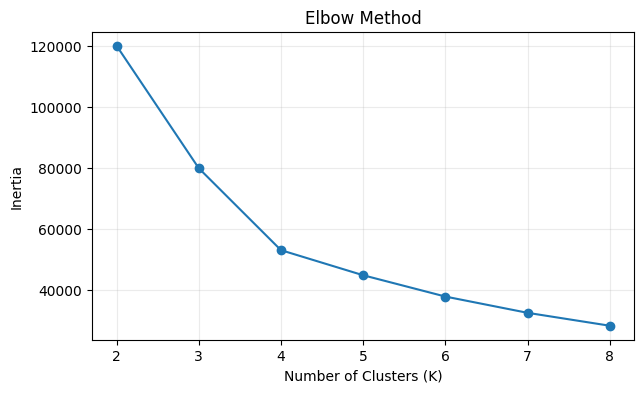

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(k_metrics['k'], k_metrics['inertia'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(alpha=0.25)
plt.show()


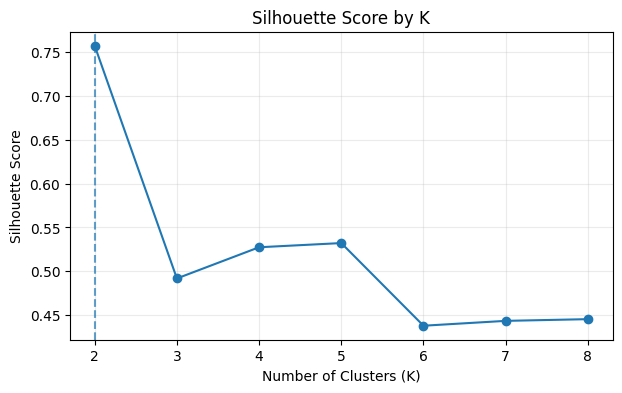

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(k_metrics['k'], k_metrics['silhouette'], marker='o')
plt.axvline(chosen_k, linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.grid(alpha=0.25)
plt.show()


## 07. Train Final K-Means Model


In [9]:
kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=20
)

rfm_pd['cluster'] = kmeans.fit_predict(rfm_scaled).astype(int)

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm_pd['cluster'],
    sample_size=silhouette_sample_size,
    random_state=42
)

print('Chosen K        :', chosen_k)
print('Silhouette Score:', round(final_silhouette, 6))
print()
print('Cluster distribution:')
print(rfm_pd['cluster'].value_counts().sort_index())


Chosen K        : 2
Silhouette Score: 0.757264

Cluster distribution:
cluster
0    54954
1     1533
Name: count, dtype: int64


## 08. Customer Segment Profile

Cluster chỉ đại diện cho hành vi mua hàng. Không gán cluster thành churn.


In [10]:
segment_profile = (
    rfm_pd
    .groupby('cluster')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        recency_mean=('recency_days', 'mean'),
        recency_median=('recency_days', 'median'),
        frequency_mean=('frequency_orders', 'mean'),
        frequency_median=('frequency_orders', 'median'),
        monetary_mean=('monetary_total', 'mean'),
        monetary_median=('monetary_total', 'median')
    )
    .reset_index()
)

segment_profile['customer_percentage'] = (
    100
    * segment_profile['customer_count']
    / segment_profile['customer_count'].sum()
)

segment_profile


,cluster,customer_count,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,customer_percentage
0,0,54954,328.698566,305.0,1.000000,1.0,157.063563,104.81,97.286101
1,1,1533,312.358774,292.0,2.097847,2.0,323.413914,215.67,2.713899


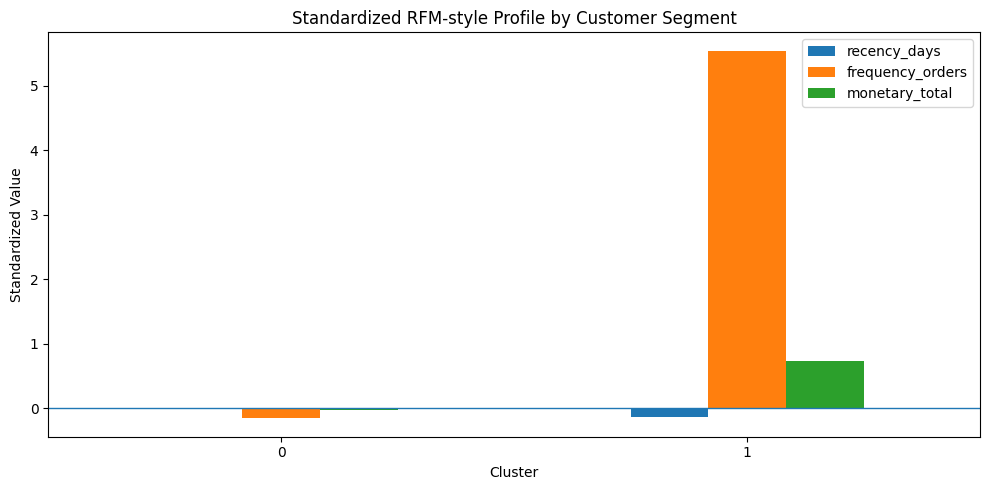

In [11]:
cluster_means = (
    rfm_pd
    .groupby('cluster')[rfm_features]
    .mean()
)

cluster_profile_scaled = pd.DataFrame(
    scaler.transform(cluster_means),
    columns=rfm_features,
    index=cluster_means.index
)

ax = cluster_profile_scaled.plot(
    kind='bar',
    figsize=(10, 5)
)
ax.set_title('Standardized RFM-style Profile by Customer Segment')
ax.set_xlabel('Cluster')
ax.set_ylabel('Standardized Value')
ax.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


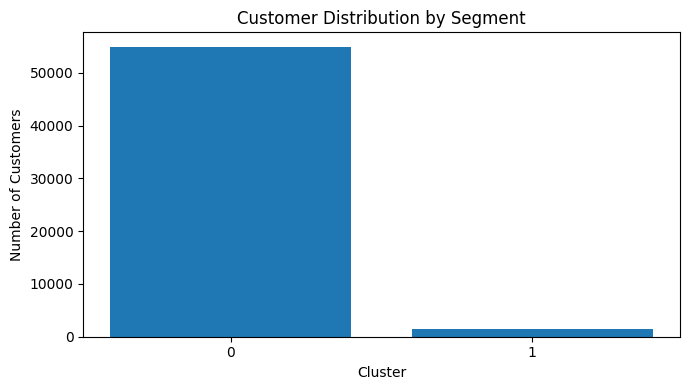

In [12]:
cluster_counts = (
    rfm_pd['cluster']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Segment')
plt.tight_layout()
plt.show()


## 09. Compare Segments with Churn (Descriptive Only)

Phần này chỉ mô tả `churn_180` tại snapshot customer-level đã chọn. `churn_180` không tham gia StandardScaler, chọn K hoặc K-Means.


In [13]:
segment_churn_summary = (
    rfm_pd
    .groupby('cluster')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        churn_rate=('churn_180', 'mean')
    )
    .reset_index()
)

segment_churn_summary['churn_rate_percent'] = (
    100 * segment_churn_summary['churn_rate']
)

segment_churn_summary['customer_percentage'] = (
    100
    * segment_churn_summary['customer_count']
    / segment_churn_summary['customer_count'].sum()
)

segment_churn_summary


,cluster,customer_count,churn_rate,churn_rate_percent,customer_percentage
0,0,54954,0.985224,98.522401,97.286101
1,1,1533,0.945205,94.520548,2.713899


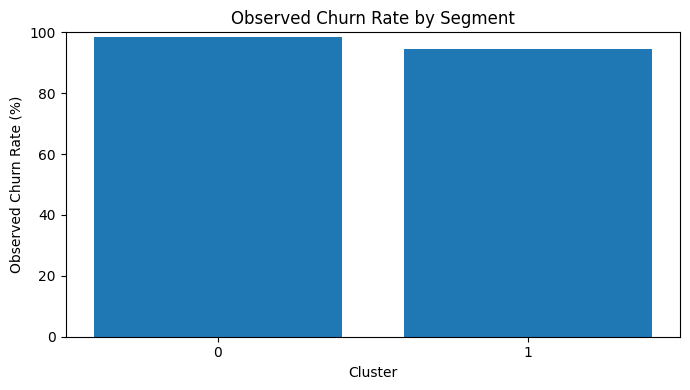

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(
    segment_churn_summary['cluster'].astype(str),
    segment_churn_summary['churn_rate_percent']
)
plt.xlabel('Cluster')
plt.ylabel('Observed Churn Rate (%)')
plt.title('Observed Churn Rate by Segment')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


## 10. Export Customer Segmentation Result


In [15]:
output_dir = processed_dir
output_dir.mkdir(parents=True, exist_ok=True)

result_path = output_dir / 'olist_customer_segmentation_result.csv'
profile_path = output_dir / 'olist_customer_segmentation_profile.csv'
k_metrics_path = output_dir / 'olist_customer_segmentation_k_metrics.csv'
metadata_path = output_dir / 'olist_customer_segmentation_metadata.json'

segment_result = rfm_pd[
    [
        'customer_unique_id',
        'snapshot_order_id',
        'snapshot_at',
        'snapshot_date',
        'recency_days',
        'frequency_orders',
        'monetary_total',
        'cluster',
        'churn_180'
    ]
].copy()

segment_result.to_csv(result_path, index=False)
segment_profile.to_csv(profile_path, index=False)
k_metrics.to_csv(k_metrics_path, index=False)

metadata = {
    'source_dataset': str(selected_feature_dir),
    'analysis_cutoff': str(analysis_cutoff),
    'customer_level_rule': 'latest snapshot per customer_unique_id',
    'rfm_mapping': {
        'recency_days': 'analysis_cutoff - latest snapshot_date',
        'frequency_orders': 'orders_last_180d at latest selected snapshot',
        'monetary_total': 'monetary_total at latest selected snapshot'
    },
    'rfm_note': 'RFM-style segmentation; frequency is 180-day frequency, not lifetime frequency.',
    'scaler': 'StandardScaler',
    'algorithm': 'KMeans',
    'k_selection': 'highest silhouette score among K=2..8; churn not used',
    'chosen_k': chosen_k,
    'random_state': 42,
    'n_init': 20,
    'silhouette_score': float(final_silhouette),
    'customer_count': int(len(segment_result)),
    'churn_used_for_clustering': False
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Export completed')
print('Result  :', result_path)
print('Profile :', profile_path)
print('K metric:', k_metrics_path)
print('Metadata:', metadata_path)


Export completed
Result  : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_segmentation_result.csv
Profile : /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_segmentation_profile.csv
K metric: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_segmentation_k_metrics.csv
Metadata: /content/drive/MyDrive/BigData/DA-BigData/code/data/processed/olist_customer_segmentation_metadata.json


## 11. Final QA


In [16]:
if segment_result['customer_unique_id'].duplicated().any():
    raise ValueError('Export result có duplicate customer_unique_id')

if segment_result[rfm_features].isna().any().any():
    raise ValueError('Export result còn missing trong RFM')

if segment_result['cluster'].isna().any():
    raise ValueError('Export result có cluster bị missing')

if segment_result['cluster'].nunique() != chosen_k:
    raise ValueError(
        f'Số cluster thực tế {segment_result["cluster"].nunique()} '
        f'không khớp chosen_k={chosen_k}'
    )

print('=' * 90)
print('CUSTOMER SEGMENTATION QA PASSED')
print('=' * 90)
print('Customers       :', f'{len(segment_result):,}')
print('RFM features    :', rfm_features)
print('Chosen K        :', chosen_k)
print('Cluster count   :', segment_result['cluster'].nunique())
print('Duplicate IDs   :', int(segment_result['customer_unique_id'].duplicated().sum()))
print('Missing RFM     :', int(segment_result[rfm_features].isna().sum().sum()))
print('Churn in KMeans :', False)


CUSTOMER SEGMENTATION QA PASSED
Customers       : 56,487
RFM features    : ['recency_days', 'frequency_orders', 'monetary_total']
Chosen K        : 2
Cluster count   : 2
Duplicate IDs   : 0
Missing RFM     : 0
Churn in KMeans : False


# Take Notes - Customer Segmentation

Đã hoàn thành:

1. Kế thừa dataset sau Feature Engineering hiện tại.
2. Chuyển từ purchase-event snapshot sang customer-level bằng snapshot gần nhất của mỗi khách hàng.
3. Tạo bộ RFM-style tương thích schema mới:
   - Recency: khoảng cách đến mốc phân tích chung.
   - Frequency: số đơn trong 180 ngày trước snapshot gần nhất.
   - Monetary: tổng giá trị mua lịch sử tại snapshot gần nhất.
4. Xử lý missing bằng median.
5. Chuẩn hóa RFM bằng StandardScaler.
6. Đánh giá K bằng Elbow và Silhouette, không dùng churn để chọn cluster.
7. Áp dụng K-Means và xây dựng profile cho từng cluster.
8. So sánh cluster với `churn_180` chỉ nhằm mục đích mô tả.
9. Export kết quả, profile, bảng đánh giá K và metadata.

Kết luận:
- Cluster không thay thế churn label.
- Cluster không được dùng để tạo `churn_180`.
- Notebook này không còn phụ thuộc vào các cột schema cũ `recency_days`, `frequency_orders`, `monetary_matched_total` từ pipeline trước.
